[2026-08-05 15:55:51] [info     ] 计算因子，区间：2022-01-01 00:00:00 ~ 2022-12-31 23:59:59


[2026-08-05 16:06:55] [info     ] 读取因子库
[2026-08-05 16:06:56] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 16:06:59] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 16:06:59] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 16:07:00] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2022-01-04 至 2022-12-30
[2026-08-05 16:07:00] [info     ] ========== 数据检查 ==========
[2026-08-05 16:07:00] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_mai


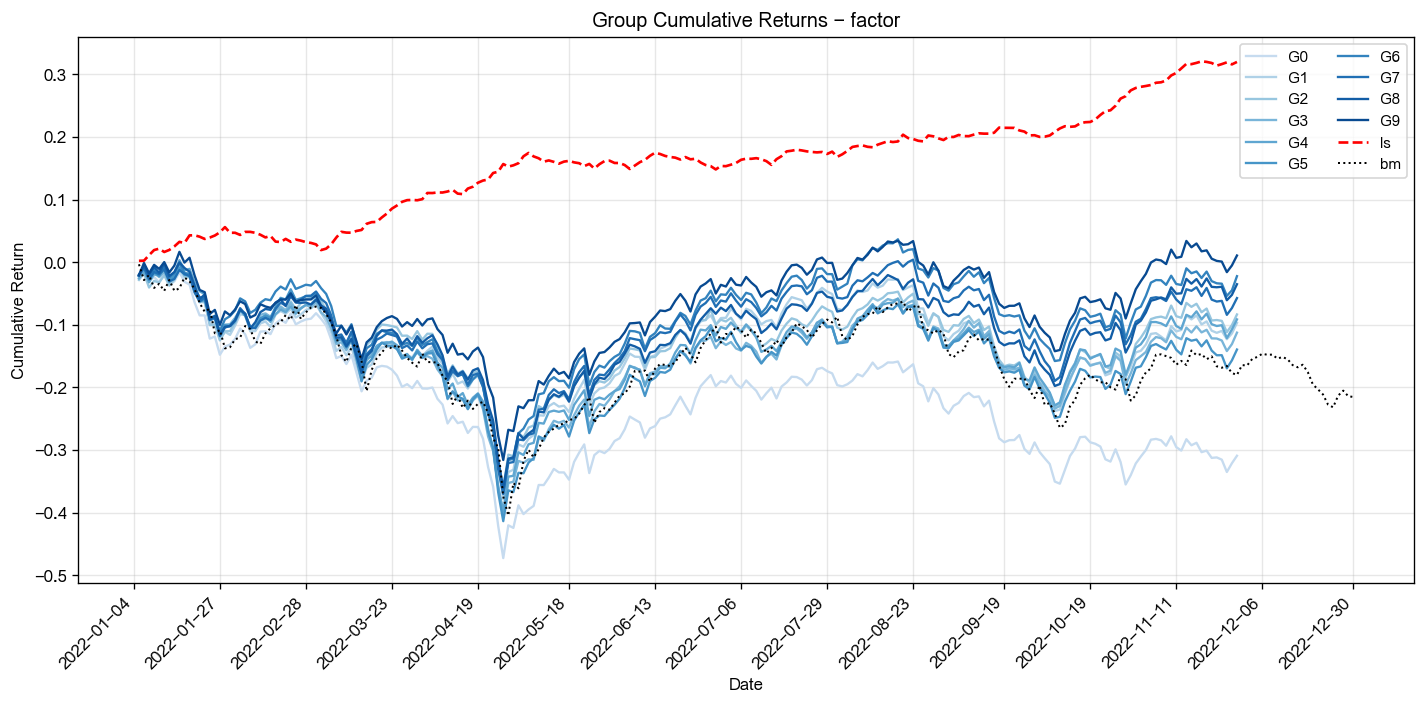
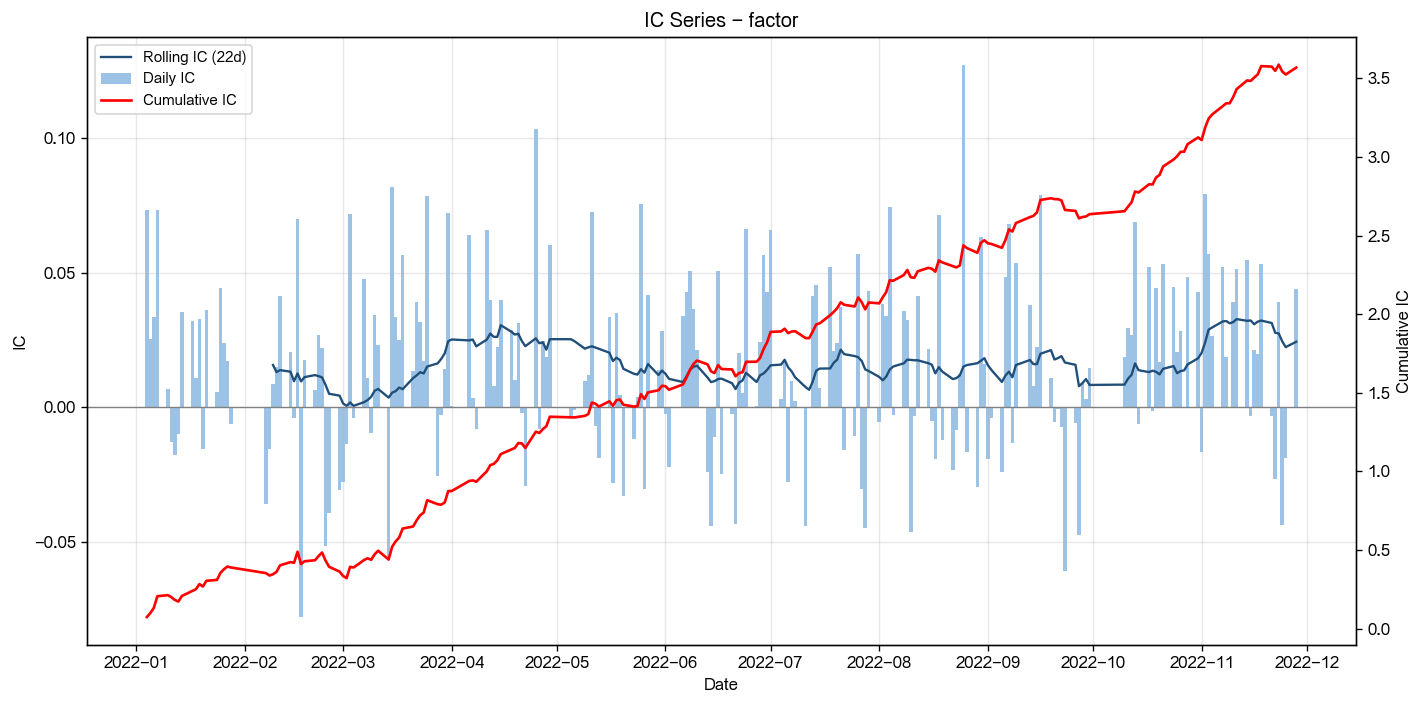
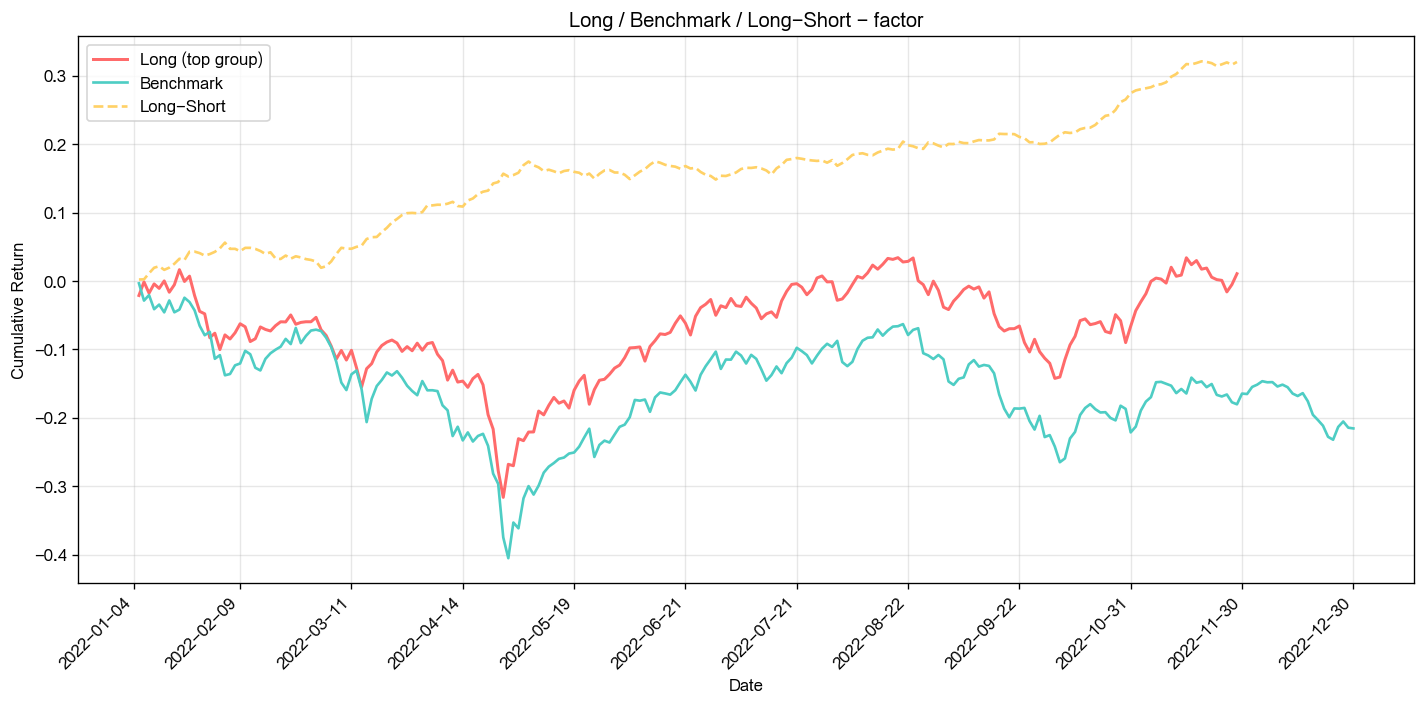

[2026-08-05 16:08:34] [info     ] ========== 因子池回归 ==========
[2026-08-05 16:08:34] [info     ] 加载 T+1 收益数据完成                  end_date=2022-12-30 instrument_count=1200 rows=295353 start_date=2022-01-04
[2026-08-05 16:08:35] [info     ] 获取收益率数据, 耗时: 1.0165 秒
[2026-08-05 16:08:36] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.8153 秒
[2026-08-05 16:08:36] [info     ] 统计 回归结果, 耗时: 0.1111 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,4.1510,0.0323,0.0078,1.0000
2,turn,2.2717,0.0348,0.0153,1.0000
3,volatility_5,2.0555,0.0175,0.0085,1.0000
4,amount,1.9197,0.0224,0.0117,1.0000
5,volume,1.8209,0.0207,0.0114,1.0000
6,beta_000300SH_22,1.8069,0.0227,0.0126,1.0000
7,cci_14,1.6441,0.0251,0.0153,1.0000
8,macd_dea_12_26_9,1.6053,0.0155,0.0097,0.9000
9,gross_profit_rate_ttm,1.5355,0.0160,0.0104,1.0000
10,float_market_cap,1.5287,0.0044,0.0029,1.0000

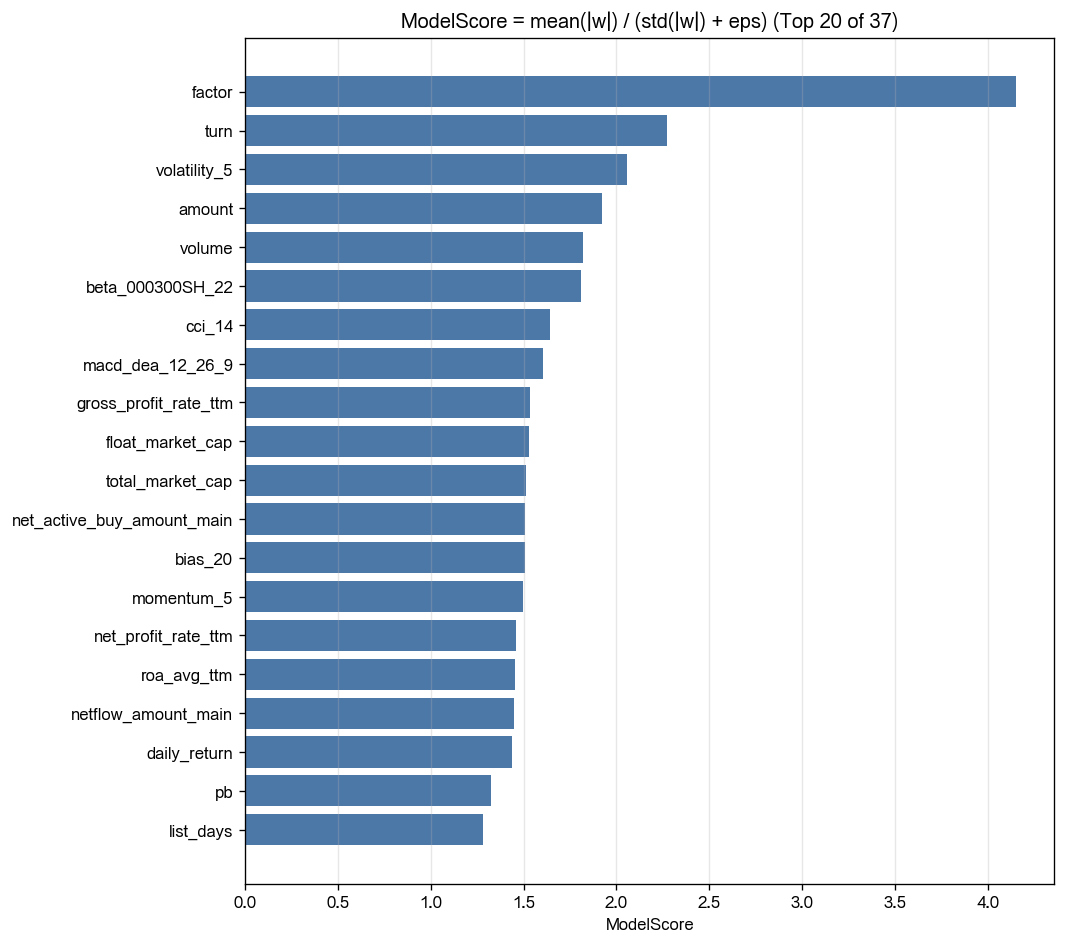
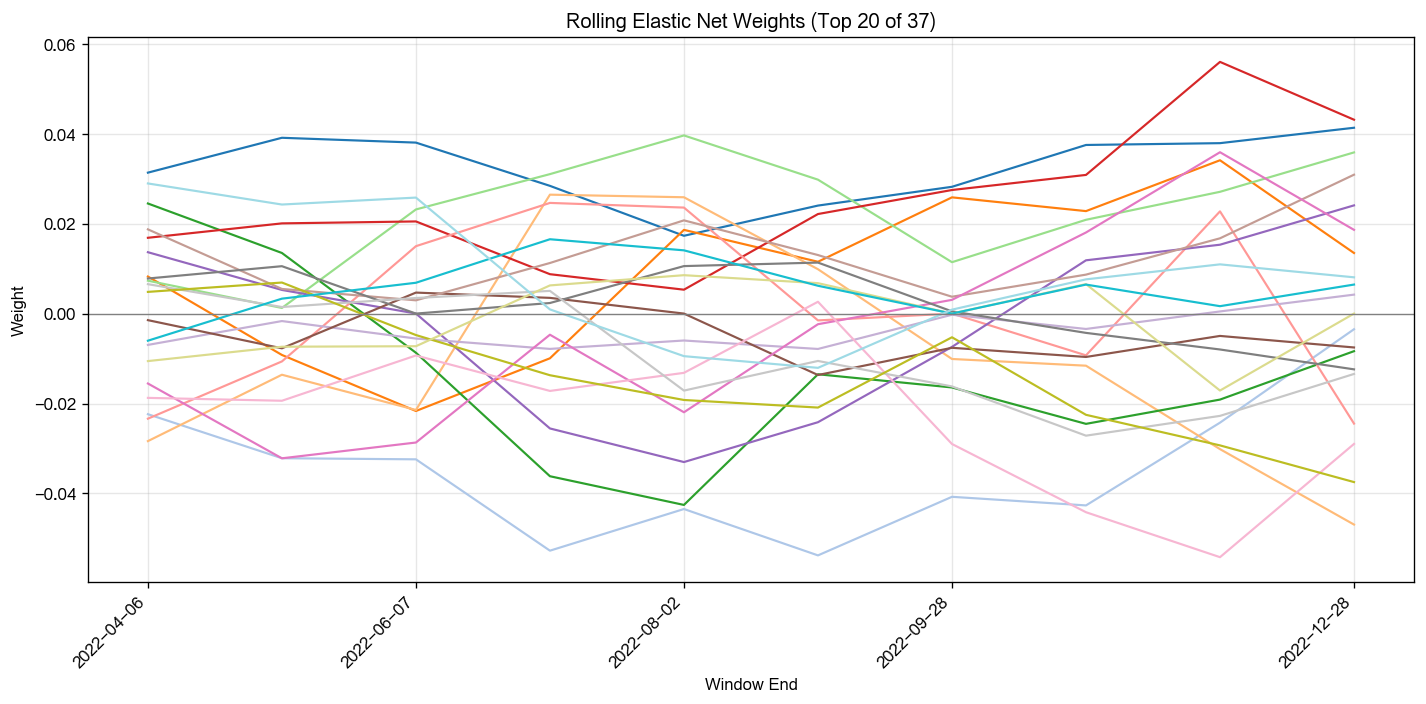
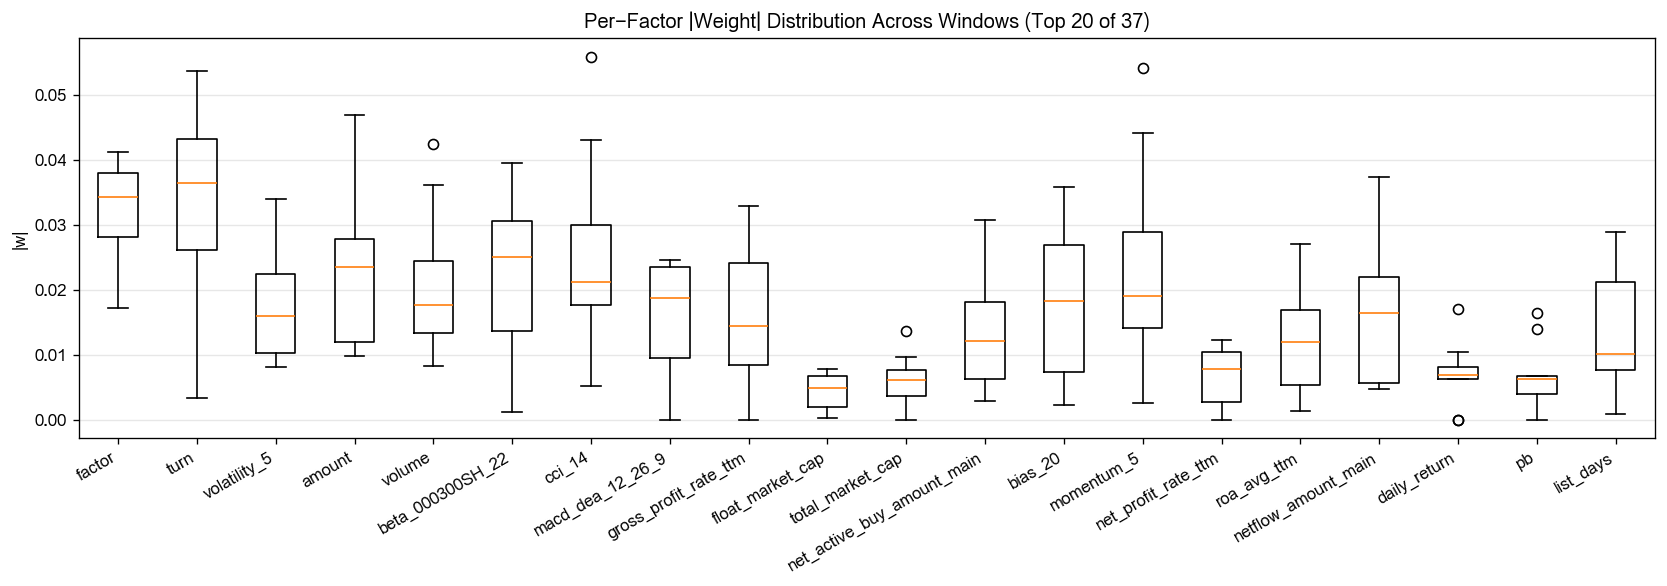
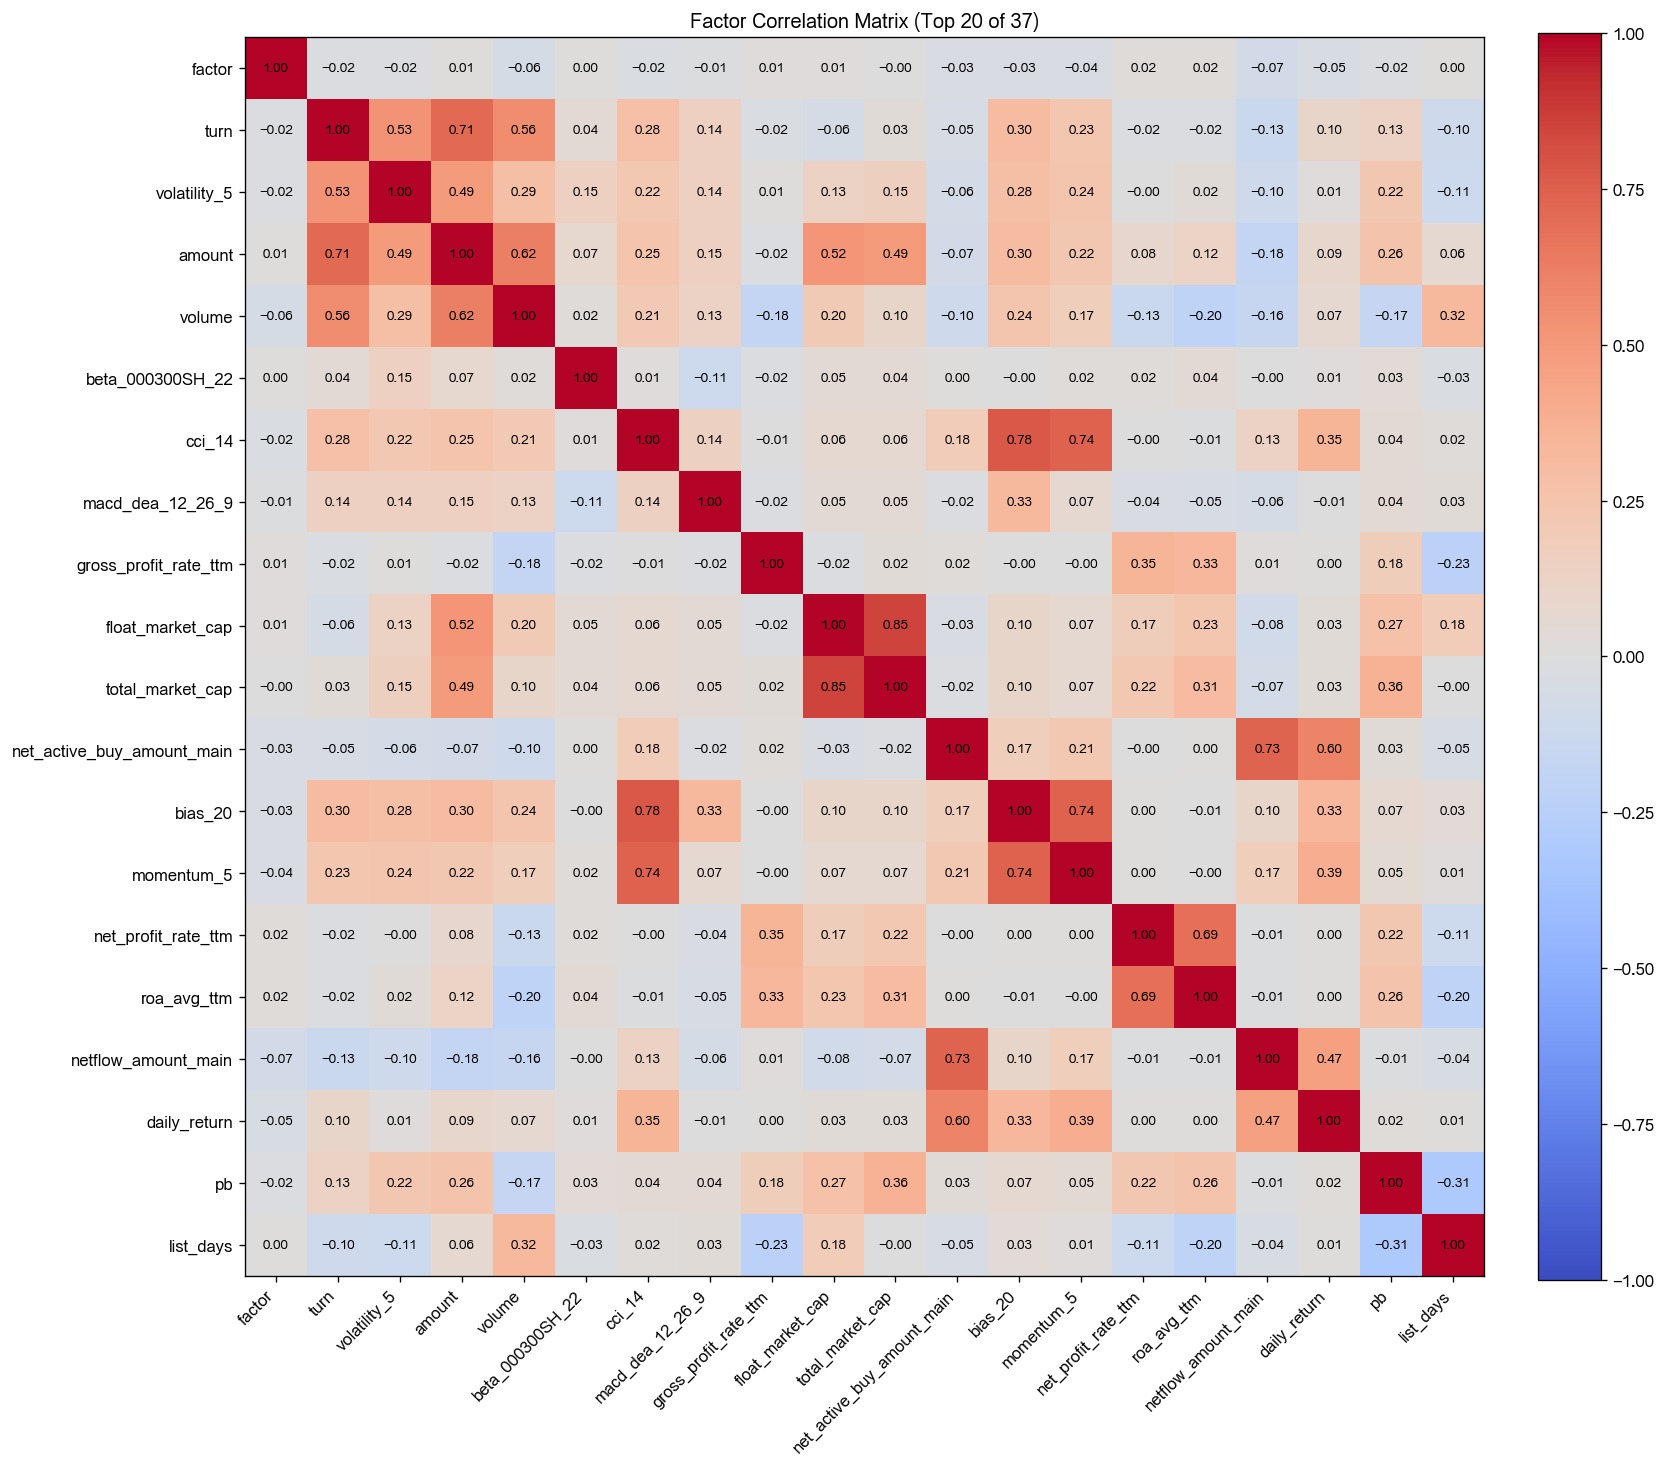

[2026-08-05 16:08:39] [warning  ] 返回的Outputs实例(size=35314431) 大于 64K, 将不会被缓存
[2026-08-05 16:08:39] [info     ] bigalpha_eval.v4 运行完成 [99.940s].


In [5]:
def main(datasources, start_date, end_date):
    import pandas as pd
    import numpy as np
    import dai

    bar1m = datasources["bar1m"]
    LOOKBACK = 90
    bar_start = (pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK)).strftime('%Y-%m-%d')
    
    # ================================================================
    # Part 1: 极端冲击集中度
    # ================================================================
    impact_sql = f"""
    WITH rets AS (
        SELECT 
            strftime(date, '%Y-%m-%d') AS trading_day,
            strftime(date, '%H:%M') AS hm,
            instrument,
            volume,
            ABS(
                ((ask_price1 + bid_price1) / 2.0 - LAG((ask_price1 + bid_price1) / 2.0) OVER (
                    PARTITION BY instrument, strftime(date, '%Y-%m-%d') ORDER BY date
                )) / NULLIF(LAG((ask_price1 + bid_price1) / 2.0) OVER (
                    PARTITION BY instrument, strftime(date, '%Y-%m-%d') ORDER BY date
                ), 0)
            ) AS abs_ret
        FROM {bar1m}
        WHERE ask_price1 > 0 AND bid_price1 > 0
    )
    SELECT 
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        MAX(abs_ret) / (SUM(abs_ret) + 1e-12) AS max_ratio,
        SUM(CASE WHEN hm >= '14:30' THEN volume ELSE 0 END) * 1.0 
            / (SUM(volume) + 1e-12) AS close_vol_ratio
    FROM rets
    WHERE abs_ret IS NOT NULL
    GROUP BY trading_day, instrument
    HAVING COUNT(*) >= 30 AND SUM(abs_ret) > 0
    """
    df_impact = dai.query(impact_sql, filters={'date': [bar_start, end_date]}, compression=True).df()
    df_impact['date'] = pd.to_datetime(df_impact['date'])
    
    # ================================================================
    # Part 2: 尾盘定价偏离
    # ================================================================
    tail_sql = f"""
    WITH minute_bars AS (
        SELECT 
            instrument,
            date,
            strftime(date, '%Y-%m-%d') AS trading_day,
            strftime(date, '%H:%M:%S') AS time_str,
            close,
            volume,
            amount,
            (ask_price1 + bid_price1) / 2.0 AS mid_price,
            high,
            low,
            ROW_NUMBER() OVER (PARTITION BY instrument, strftime(date, '%Y-%m-%d') 
                            ORDER BY date DESC) AS bar_num_rev
        FROM {bar1m}
        WHERE close > 0 AND volume > 0
    ),
    
    time_segments AS (
        SELECT 
            trading_day,
            instrument,
            date,
            close,
            volume,
            amount,
            mid_price,
            high,
            low,
            CASE 
                WHEN time_str >= '14:57:00' THEN 'close_auction'
                WHEN time_str >= '14:30:00' AND time_str < '14:57:00' THEN 'late_session'
                WHEN time_str >= '13:30:00' AND time_str < '14:30:00' THEN 'afternoon'
                ELSE 'other'
            END AS time_segment
        FROM minute_bars
        WHERE bar_num_rev <= 240
    ),
    
    segment_stats AS (
        SELECT 
            trading_day,
            instrument,
            MAX(CASE WHEN time_segment = 'close_auction' THEN close END) AS close_price,
            SUM(CASE WHEN time_segment = 'late_session' THEN amount ELSE 0 END) / 
                NULLIF(SUM(CASE WHEN time_segment = 'late_session' THEN volume ELSE 0 END), 0) 
                AS late_vwap,
            SUM(CASE WHEN time_segment = 'afternoon' THEN amount ELSE 0 END) / 
                NULLIF(SUM(CASE WHEN time_segment = 'afternoon' THEN volume ELSE 0 END), 0) 
                AS afternoon_vwap,
            SUM(CASE WHEN time_segment = 'close_auction' THEN volume ELSE 0 END) * 1.0 / 
                NULLIF(SUM(volume), 0) AS tail_close_vol_ratio,
            STDDEV(CASE WHEN time_segment = 'late_session' THEN close END) / 
                NULLIF(AVG(CASE WHEN time_segment = 'late_session' THEN close END), 0) 
                AS late_volatility,
            AVG(CASE WHEN time_segment = 'close_auction' 
                THEN (high - low) / NULLIF(mid_price, 0) END) AS close_spread,
            SUM(volume) AS total_volume
        FROM time_segments
        GROUP BY trading_day, instrument
        HAVING close_price IS NOT NULL 
        AND late_vwap IS NOT NULL 
        AND afternoon_vwap IS NOT NULL
        AND total_volume > 0
    ),
    
    price_pressure AS (
        SELECT 
            trading_day,
            instrument,
            (close_price - late_vwap) / NULLIF(late_vwap, 0) AS close_vs_late,
            (late_vwap - afternoon_vwap) / NULLIF(afternoon_vwap, 0) AS late_vs_afternoon,
            tail_close_vol_ratio,
            late_volatility,
            close_spread
        FROM segment_stats
    )
    
    SELECT 
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        close_vs_late,
        late_vs_afternoon,
        tail_close_vol_ratio,
        late_volatility,
        close_spread
    FROM price_pressure
    WHERE close_vs_late IS NOT NULL
    AND ABS(close_vs_late) < 0.05
    """
    
    df_tail = dai.query(tail_sql, filters={'date': [bar_start, end_date]}, compression=True).df()
    df_tail['date'] = pd.to_datetime(df_tail['date'])
    
    # ================================================================
    # Part 3: 合并数据
    # ================================================================
    df = pd.merge(df_tail, df_impact, on=['date', 'instrument'], how='inner')
    df = df.sort_values(['instrument', 'date'])
    
    # 行业数据
    ind_df = dai.query(
        "SELECT date, instrument, industry_level1_code FROM bigalpha_2026_exposure",
        filters={'date': [start_date, end_date]}
    ).df()
    ind_df['date'] = pd.to_datetime(ind_df['date'])
    df = pd.merge(df, ind_df, on=['date', 'instrument'], how='left')
    df['industry_level1_code'] = df['industry_level1_code'].fillna('unknown')
    
    # ================================================================
    # Part 4: 构造尾盘原始信号
    # ================================================================
    # 反转信号
    df['mispricing_signal'] = -df['close_vs_late']
    
    # 加权：成交量异常
    df['volume_weight'] = (
        df['tail_close_vol_ratio'] - 
        df.groupby('date')['tail_close_vol_ratio'].transform('median')
    ).clip(0, None)
    
    # 加权：波动率异常
    df['vol_weight'] = (
        df['late_volatility'] - 
        df.groupby('date')['late_volatility'].transform('median')
    ).clip(0, None)
    
    # 压力过滤
    df['spread_signal'] = df.groupby('date')['close_spread'].rank(pct=True)
    df.loc[df['spread_signal'] < 0.3, 'mispricing_signal'] = 0
    
    # 合成原始信号
    df['tail_raw'] = (
        df['mispricing_signal'] * 
        (1 + df['volume_weight']) *
        (1 + df['vol_weight'])
    )
    
    # 趋势过滤
    df['trend_filter'] = (
        (df['late_vs_afternoon'] > 0) & (df['close_vs_late'] > 0) |
        (df['late_vs_afternoon'] < 0) & (df['close_vs_late'] < 0)
    )
    df.loc[~df['trend_filter'], 'tail_raw'] *= 0.5
    
    # ================================================================
    # Part 5: 冲击集中度作为信号质量过滤器（核心改进）
    # ================================================================
    # 行业内排名
    def ind_rank(frame, col):
        return (
            frame.groupby(['date', 'industry_level1_code'])[col]
            .rank(pct=True) - 0.5
        )
    
    df['r_impact'] = ind_rank(df, 'max_ratio')
    df['r_close_vol'] = ind_rank(df, 'close_vol_ratio')
    
    # 冲击集中度逻辑：
    # 1. 高集中度 = 少数极端分钟主导 = 情绪脉冲 → 尾盘偏离更可能反转
    # 2. 低集中度 = 全天均匀波动 = 趋势延续 → 尾盘偏离可能是噪音
    
    # 信号质量得分（0.7 ~ 1.3）
    df['impact_quality'] = 1.0 + 0.6 * df['r_impact'].clip(-0.5, 0.5)
    
    # 额外增强：高集中度 + 尾盘放量 → 情绪冲动更确定
    df['volume_confirmation'] = np.where(
        (df['r_impact'] > 0.2) & (df['r_close_vol'] > 0.2),
        1.2,  # 同时满足时放大1.2倍
        1.0
    )
    
    # 合成最终信号
    df['factor_raw'] = df['tail_raw'] * df['impact_quality'] * df['volume_confirmation']
    
    # ================================================================
    # Part 6: 行业内标准化 + 时间平滑
    # ================================================================
    df = df[df['date'] >= pd.to_datetime(start_date)].copy()
    
    def cross_zscore(frame, col, group):
        mean = frame.groupby(['date', group])[col].transform('mean')
        std  = frame.groupby(['date', group])[col].transform('std')
        return (frame[col] - mean) / (std + 1e-8)
    
    df['factor_neutral'] = cross_zscore(df, 'factor_raw', 'industry_level1_code')
    
    # 时间平滑
    df = df.sort_values(['instrument', 'date'])
    df['factor'] = (
        df.groupby('instrument')['factor_neutral']
        .transform(lambda x: x.ewm(span=3, min_periods=1).mean())
    )
    
    # ================================================================
    # Part 7: 输出
    # ================================================================
    result = df[['date', 'instrument', 'factor']].dropna()
    result = result[np.isfinite(result['factor'])]
    
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]}
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    
    final = pd.merge(stk_pool, result, how='left', on=['date', 'instrument'])
    final = pd.merge(final, ind_df, on=['date', 'instrument'], how='left')
    final['industry_level1_code'] = final['industry_level1_code'].fillna('unknown')
    
    # 缺失值填充
    ind_median = final.groupby(['date', 'industry_level1_code'])['factor'].transform('median')
    date_median = final.groupby('date')['factor'].transform('median')
    final['factor'] = final['factor'].fillna(ind_median).fillna(date_median).fillna(0.0)
    final = final[np.isfinite(final['factor'])]
    
    return final[['date', 'instrument', 'factor']]


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
